In [ ]:
import requests
import pandas as pd

# Endpoint URL
url = "https://api.nhtsa.gov/complaints/complaintsByVehicle"

# Parameters for the API request
params = {
    "make": "toyota",
    "model": "corolla",
    "modelYear": "2017"
}

# Making the GET request
response = requests.get(url, params=params)

# Checking if the request was successful
if response.status_code == 200:
    data = response.json()
    print(data)
else:
    print("Error: " + str(response.status_code))

{'count': 172, 'message': 'Results returned successfully', 'results': [{'odiNumber': 11640746, 'manufacturer': 'Toyota Motor Corporation', 'crash': True, 'fire': False, 'numberOfInjuries': 0, 'numberOfDeaths': 0, 'dateOfIncident': '02/02/2025', 'dateComplaintFiled': '02/04/2025', 'vin': '2T1BURHE0HC', 'components': 'STEERING,ELECTRICAL SYSTEM', 'summary': 'While turning left out of a drive through my the steering locked up and shot to the left causing a run up on the curb. However after a second or two it cleared. Upon shutting the car off and restarting driving in a parking lot same problem occured steering wheel shot to left causing me to almost loose control then all electrical power was lost in the vehicle. The steering wheel fault came up on the dash and would not let me control the wheel.', 'products': [{'type': 'Vehicle', 'productYear': '2017', 'productMake': 'TOYOTA', 'productModel': 'COROLLA', 'manufacturer': 'Toyota Motor Corporation'}]}, {'odiNumber': 11633935, 'manufacturer

In [ ]:
complaints = pd.DataFrame(data['results'])

In [ ]:
complaints.head()

,odiNumber,manufacturer,crash,fire,numberOfInjuries,numberOfDeaths,dateOfIncident,dateComplaintFiled,vin,components,summary,products
0,11640746,Toyota Motor Corporation,True,False,0,0,02/02/2025,02/04/2025,2T1BURHE0HC,"STEERING,ELECTRICAL SYSTEM",While turning left out of a drive through my t...,"[{'type': 'Vehicle', 'productYear': '2017', 'p..."
1,11633935,Toyota Motor Corporation,False,False,0,0,11/15/2024,01/03/2025,2T1BURHE4HC,AIR BAGS,The contact owns a 2017 Toyota Corolla. The co...,"[{'type': 'Vehicle', 'productYear': '2017', 'p..."
2,11633253,Toyota Motor Corporation,False,False,0,0,12/30/2024,12/30/2024,5YFBURHE1HP,SERVICE BRAKES,Drum Brakes - no inspection hole. There are no...,"[{'type': 'Vehicle', 'productYear': '2017', 'p..."
3,11626350,Toyota Motor Corporation,False,False,0,0,11/01/2024,11/20/2024,JTNKARJE3HJ,VISIBILITY,A/C compressor Non-functioning A/C affects wi...,"[{'type': 'Vehicle', 'productYear': '2017', 'p..."
4,11620410,Toyota Motor Corporation,True,False,4,0,10/16/2024,10/17/2024,5YFBURHE6HP,AIR BAGS,I was driving for work and got into a pretty b...,"[{'type': 'Vehicle', 'productYear': '2017', 'p..."


In [ ]:
print(complaints['components'].str.split(',\s+', expand=True).stack().value_counts())

AIR BAGS                                                                   31
VEHICLE SPEED CONTROL                                                      15
UNKNOWN OR OTHER                                                           13
SERVICE BRAKES                                                             11
POWER TRAIN                                                                 7
                                                                           ..
UNKNOWN OR OTHER,FORWARD COLLISION AVOIDANCE                                1
VEHICLE SPEED CONTROL,SERVICE BRAKES,VISIBILITY/WIPER                       1
AIR BAGS,STRUCTURE,WHEELS,UNKNOWN OR OTHER                                  1
VEHICLE SPEED CONTROL,ELECTRONIC STABILITY CONTROL (ESC),SERVICE BRAKES     1
ELECTRICAL SYSTEM,FORWARD COLLISION AVOIDANCE                               1
Name: count, Length: 70, dtype: int64


In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

**The world cloud shows the most common problem with the largest text and everything under it slowly decreases its text size to the least common problem**

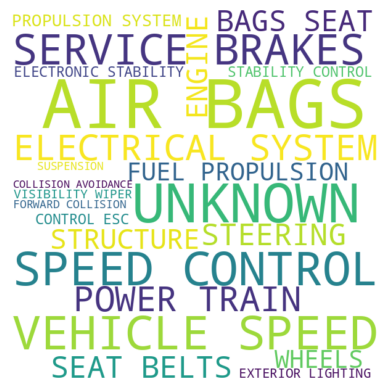

In [ ]:
text_data = complaints['components'].str.cat(sep=' ')

wc = WordCloud(min_font_size=16, max_words=100, background_color="white",width=600,height=600).generate(text_data)
plt.figure()
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

In [ ]:
wc.to_file("toyota_wc.png")

In [ ]:
complaints.to_csv('toyota_corolla_complaints.csv', index=False)